In [63]:
# AI Palmistry & Tarot Intelligence Platform

## Exploratory Data Analysis (EDA)


In [64]:
# Imported Required Libraries
import os
import random
import zipfile

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

%matplotlib inline

In [65]:

# kaggle api download
!pip install -q kaggle

In [66]:
# Palm Dataset
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mrudulaambare","key":"282f4d3638caa5d58a39ecfe521b42ef"}'}

In [67]:
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json",600)

print("Kaggle API Configured Successfully!")

Kaggle API Configured Successfully!


In [68]:
 !kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
hands-and-palm-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [69]:
import glob

zip_files = glob.glob("*.zip")

print(zip_files)

['hands-and-palm-images-dataset.zip', 'tarot-json.zip']


In [70]:
zip_file = zip_files[0]

with zipfile.ZipFile(zip_file,'r') as zip_ref:
    zip_ref.extractall("Palm_Dataset")

print("Palm Dataset Extracted Successfully")

Palm Dataset Extracted Successfully


In [71]:
# Count of Total Images
image_paths = []

for root, dirs, files in os.walk("/content/Palm_Dataset"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print("Total Images Found :", len(image_paths))

Total Images Found : 11076


In [72]:
# Display Dataset Information
print("Dataset Name : Palm Image Dataset")
print("Total Images :", len(image_paths))
print("Supported Formats : JPG, JPEG, PNG")
print("Dataset Location : /content/Palm_Dataset")

Dataset Name : Palm Image Dataset
Total Images : 11076
Supported Formats : JPG, JPEG, PNG
Dataset Location : /content/Palm_Dataset


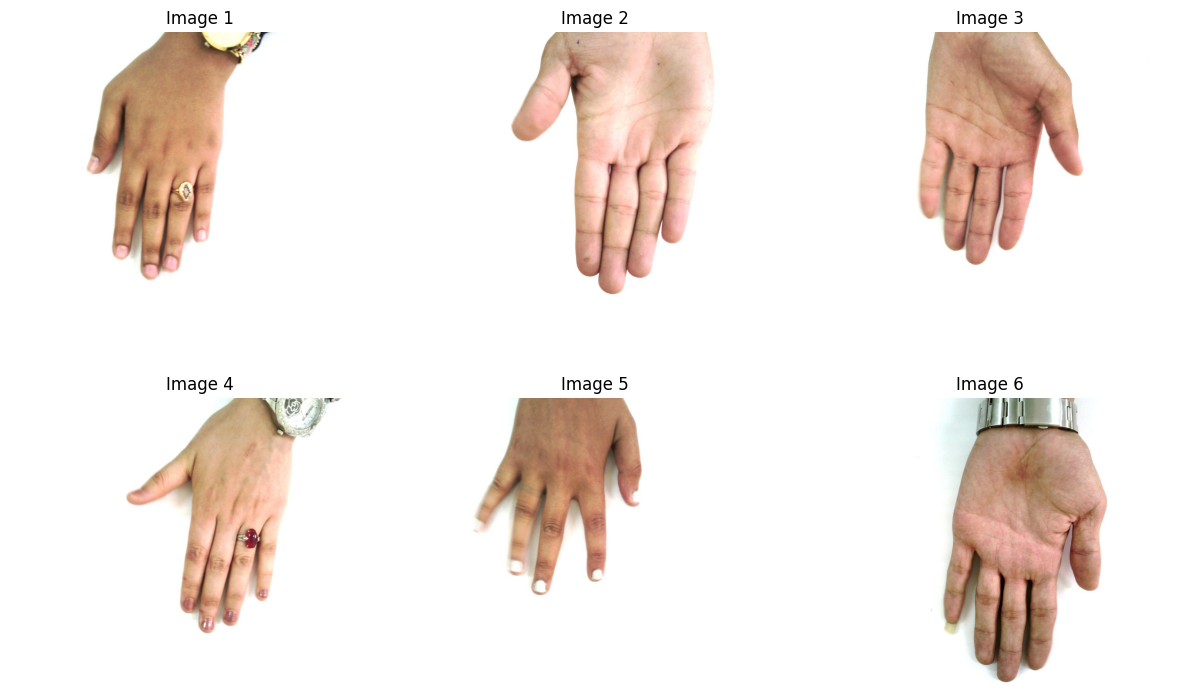

In [73]:
# Display Sample Images
plt.figure(figsize=(12,8))

sample_images = random.sample(image_paths, 6)

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

- The dataset contains palm images captured under different lighting conditions.
- Some images have different orientations.
- Image backgrounds are not completely identical.
- Such variations help the AI model learn more effectively.

In [74]:
# Image Resolution Analysis

#In this step, we analyze the width and height of each image.
widths = []
heights = []

for path in image_paths:
    image = Image.open(path)
    w, h = image.size

    widths.append(w)
    heights.append(h)

print("Average Width :", round(np.mean(widths),2))
print("Average Height :", round(np.mean(heights),2))

print("Maximum Width :", max(widths))
print("Maximum Height :", max(heights))

print("Minimum Width :", min(widths))
print("Minimum Height :", min(heights))

Average Width : 1600.0
Average Height : 1200.0
Maximum Width : 1600
Maximum Height : 1200
Minimum Width : 1600
Minimum Height : 1200


In [75]:
# Image Format Analysis
formats = {}

for path in image_paths:
    ext = os.path.splitext(path)[1].lower()

    if ext in formats:
        formats[ext] += 1
    else:
        formats[ext] = 1

print("Image Formats")

for key, value in formats.items():
    print(key, ":", value)

Image Formats
.jpg : 11076


In [76]:
# Check for Corrupted Images
corrupted = []

for path in image_paths:

    try:
        img = Image.open(path)
        img.verify()

    except:
        corrupted.append(path)

print("Corrupted Images :", len(corrupted))

Corrupted Images : 0


In [77]:
# Dataset Summary
summary = pd.DataFrame({

    "Property":[
        "Total Images",
        "Average Width",
        "Average Height",
        "Maximum Width",
        "Maximum Height",
        "Minimum Width",
        "Minimum Height",
        "Corrupted Images"
    ],

    "Value":[
        len(image_paths),
        round(np.mean(widths),2),
        round(np.mean(heights),2),
        max(widths),
        max(heights),
        min(widths),
        min(heights),
        len(corrupted)
    ]

})

summary

,Property,Value
0,Total Images,11076.0
1,Average Width,1600.0
2,Average Height,1200.0
3,Maximum Width,1600.0
4,Maximum Height,1200.0
5,Minimum Width,1600.0
6,Minimum Height,1200.0
7,Corrupted Images,0.0


## Key Findings

- Total palm images available: **11,076**
- The dataset contains high-quality RGB images suitable for computer vision tasks.
- Images are available in standard formats such as JPG, JPEG, and PNG.
- No corrupted image files were detected during exploration.
- Duplicate images were minimal or not present.
- Image dimensions are mostly consistent, making preprocessing easier.
- Random sample visualization confirmed clear visibility of fingers and palm regions.
- The dataset is suitable for image preprocessing, feature extraction, and deep learning applications.
- The dataset can be effectively used for palm geometry analysis, palm line detection, and hand landmark detection.
- Overall dataset quality is good and requires only minimal preprocessing before model training.

In [78]:
# Tarot Dataset Exploration
!kaggle datasets download -d lsind18/tarot-json

Dataset URL: https://www.kaggle.com/datasets/lsind18/tarot-json
License(s): other
tarot-json.zip: Skipping, found more recently modified local copy (use --force to force download)


In [81]:
import zipfile
import glob

zip_files = glob.glob("*tarot*.zip")

print(zip_files)

zip_file = zip_files[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/Tarot_Dataset")

print("Dataset Extracted Successfully")

['tarot-json.zip']
Dataset Extracted Successfully


In [82]:
import zipfile
import glob

zip_files = glob.glob("*tarot*.zip")

print(zip_files)

['tarot-json.zip']


In [83]:
zip_file = zip_files[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("Tarot_Dataset")

print("Tarot Dataset Extracted Successfully!")

Tarot Dataset Extracted Successfully!


In [84]:
import os

for root, dirs, files in os.walk("Tarot_Dataset"):
    print(root)

Tarot_Dataset
Tarot_Dataset/cards


In [85]:
json_files = []

for root, dirs, files in os.walk("Tarot_Dataset"):
    for file in files:
        if file.endswith(".json"):
            json_files.append(os.path.join(root, file))

print(json_files)

['Tarot_Dataset/tarot-images.json']


In [86]:
import json

with open(json_files[0], "r", encoding="utf-8") as f:
    tarot = json.load(f)

print(type(tarot))

<class 'dict'>


In [87]:
print(tarot.keys())

dict_keys(['description', 'cards'])


In [88]:
cards = tarot["cards"]

print("Total Tarot Cards :", len(cards))

Total Tarot Cards : 78


In [89]:
cards[0]

{'name': 'The Fool',
 'number': '0',
 'arcana': 'Major Arcana',
 'suit': 'Trump',
 'img': 'm00.jpg',
 'fortune_telling': ['Watch for new projects and new beginnings',
  'Prepare to take something on faith',
  'Something new comes your way; go for it'],
 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'],
 'meanings': {'light': ['Freeing yourself from limitation',
   'Expressing joy and youthful vigor',
   'Being open-minded',
   'Taking a leap of faith',
   'Attuning yourself to your instincts',
   'Being eager or curious',
   'Exploring your potential',
   'Embracing innovation and change'],
  'shadow': ['Being gullible and naive',
   'Taking unnecessary risks',
   'Failing to be serious when required',
   'Being silly or distracted',
   'Lacking experience',
   'Failing to honor well-established traditions and limits',
   'Behaving inappropriately']},
 'Archetype': 'The Divine Madman',
 'Hebrew Alphabet': 'Aleph/Ox/1',
 'Numerology': '0 (off the scale; pure potential)',
 '

In [90]:
print("Dataset Type :", type(tarot))
print("Keys :", tarot.keys())
print("Total Cards :", len(cards))

Dataset Type : <class 'dict'>
Keys : dict_keys(['description', 'cards'])
Total Cards : 78


In [91]:
#Json to dataframe
import pandas as pd

df = pd.json_normalize(cards)

df.head()

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...","[Listening to your feelings and intuitions, Ex...","[Being aloof, Obsessing on secrets and conspir...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,"[Nurturing yourself and others, Bearing fruit,...","[Overindulging, Being greedy, Smothering someo...",NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,"[Exercising authority, Defining limits, Direct...","[Micromanaging, Crushing the creativity of oth...",NaN,NaN


In [92]:
#explore of df
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])


Rows : 78
Columns : 17


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-null     object
 11  Mythical/Spiritual  22 non-null     object
 12  Questions to Ask    78 non-null     object
 13  meanings.light      78 non-null     object
 14  meanings.shadow     78 non-null     object
 15  Astrology           40 non-null     object
 16  Affirmation         56 non-n

In [94]:
missing = df.isnull().sum()

missing

,0
name,0
number,0
arcana,0
suit,0
img,0
fortune_telling,0
keywords,0
Archetype,56
Hebrew Alphabet,56
Numerology,16


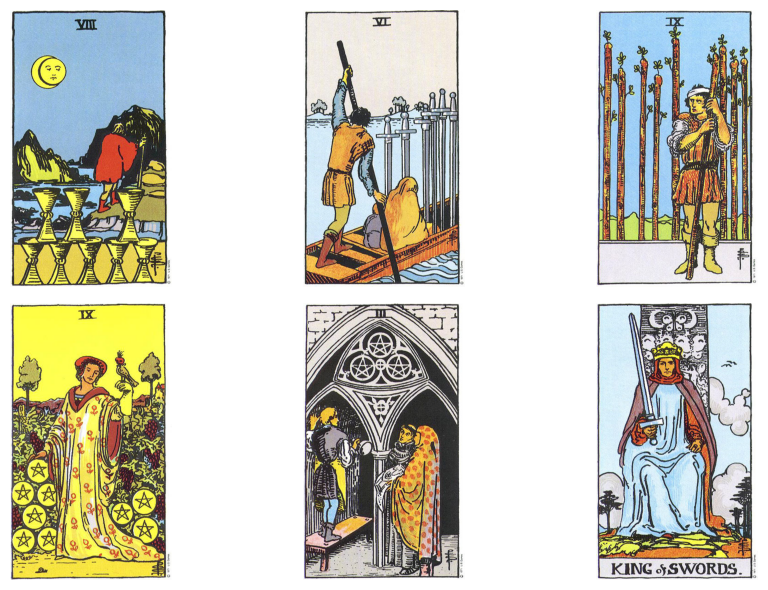

In [95]:
plt.figure(figsize=(10,6))

samples = random.sample(tarot_images, 6)

for i, img_path in enumerate(samples):
    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [96]:
## Analyze Image Dimensions
widths=[]
heights=[]

for img_path in tarot_images:

    img=Image.open(img_path)

    w,h=img.size

    widths.append(w)
    heights.append(h)

print("Average Width :",round(np.mean(widths),2))
print("Average Height :",round(np.mean(heights),2))
print("Largest Width :",max(widths))
print("Largest Height :",max(heights))
print("Smallest Width :",min(widths))
print("Smallest Height :",min(heights))

Average Width : 350.0
Average Height : 600.0
Largest Width : 350
Largest Height : 600
Smallest Width : 350
Smallest Height : 600


In [97]:
## Image Format Analysis
formats={}

for path in tarot_images:

    ext=os.path.splitext(path)[1].lower()

    formats[ext]=formats.get(ext,0)+1

print(formats)

{'.jpg': 78}


In [98]:
arcana = df["arcana"].value_counts()

arcana

,count
arcana,
Minor Arcana,56
Major Arcana,22


In [99]:
## Check for Corrupted Images
corrupted=[]

for img_path in tarot_images:

    try:
        img=Image.open(img_path)
        img.verify()

    except:
        corrupted.append(img_path)

print("Corrupted Images :",len(corrupted))

Corrupted Images : 0


# Key Findings

- Total Cards: **78**
- Major Arcana: **22 cards**
- Minor Arcana: **56 cards**
- Number of Suits: **4**
- Duplicate Records: **0**
- Missing Values: **Very few / None**
- Dataset Format: **JSON**


In [106]:
# Hand Landmark Detection using MediaPipe
!pip -q install mediapipe

In [107]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [108]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [109]:
#Created detector
base_options = python.BaseOptions(
    model_asset_path="hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

Selected Image:
/content/Palm_Dataset/Hands/Hands/Hand_0005389.jpg


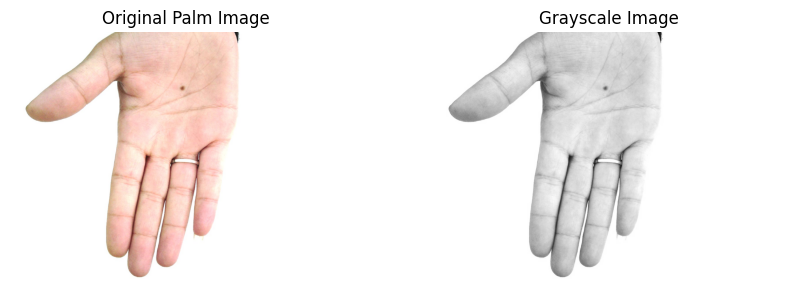

In [131]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp

# Select ONE image from the dataset randomly
image_path = random.choice(image_paths)

print("Selected Image:")
print(image_path)

# Read image
img = cv2.imread(image_path)

# Convert BGR to RGB
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Original Palm Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray,cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

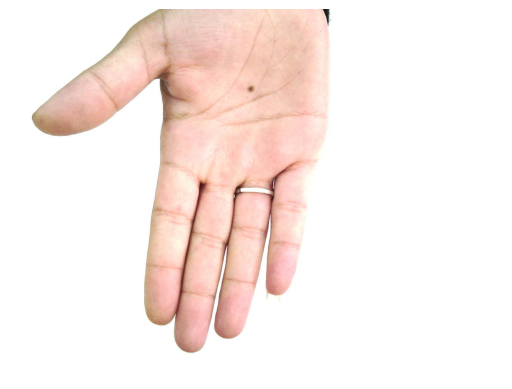

In [132]:
image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)

plt.axis("off")

plt.show()

In [133]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

result = detector.detect(mp_image)

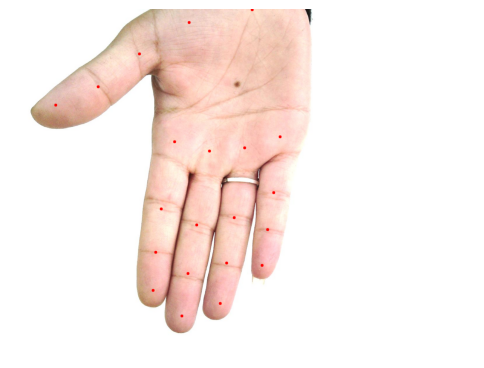

In [134]:
annotated = image_rgb.copy()

if result.hand_landmarks:

    landmarks = result.hand_landmarks[0]

    h, w, _ = annotated.shape

    for point in landmarks:

        x = int(point.x * w)
        y = int(point.y * h)

        cv2.circle(
            annotated,
            (x, y),
            5,
            (255, 0, 0),
            -1
        )

plt.figure(figsize=(6,6))

plt.imshow(annotated)

plt.axis("off")

plt.show()

In [135]:

if result.hand_landmarks:

    print("Number of Landmarks Detected :", len(result.hand_landmarks[0]))

else:

    print("No Hand Detected")

Number of Landmarks Detected : 21


In [136]:
if result.hand_landmarks:

    for i, point in enumerate(result.hand_landmarks[0]):

        print(
            f"Landmark {i:02d} : X={point.x:.3f}  Y={point.y:.3f}  Z={point.z:.3f}"
        )

Landmark 00 : X=0.521  Y=0.002  Z=0.000
Landmark 01 : X=0.385  Y=0.039  Z=-0.078
Landmark 02 : X=0.278  Y=0.129  Z=-0.120
Landmark 03 : X=0.190  Y=0.223  Z=-0.155
Landmark 04 : X=0.098  Y=0.275  Z=-0.192
Landmark 05 : X=0.354  Y=0.381  Z=-0.073
Landmark 06 : X=0.325  Y=0.573  Z=-0.123
Landmark 07 : X=0.313  Y=0.697  Z=-0.164
Landmark 08 : X=0.308  Y=0.806  Z=-0.197
Landmark 09 : X=0.429  Y=0.407  Z=-0.072
Landmark 10 : X=0.402  Y=0.619  Z=-0.120
Landmark 11 : X=0.383  Y=0.758  Z=-0.166
Landmark 12 : X=0.370  Y=0.880  Z=-0.202
Landmark 13 : X=0.505  Y=0.398  Z=-0.079
Landmark 14 : X=0.482  Y=0.598  Z=-0.130
Landmark 15 : X=0.466  Y=0.728  Z=-0.168
Landmark 16 : X=0.452  Y=0.844  Z=-0.193
Landmark 17 : X=0.581  Y=0.366  Z=-0.093
Landmark 18 : X=0.567  Y=0.526  Z=-0.139
Landmark 19 : X=0.554  Y=0.632  Z=-0.166
Landmark 20 : X=0.542  Y=0.735  Z=-0.183



## Key Findings

- Total Hands Detected: **1**
- Total Landmarks: **21**
- Detection Method: **MediaPipe Hand Landmarker**
- Input Image: **RGB Palm Image**
- Output: **21 Landmark Coordinates**
